In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Define learn function
# deg is the highest degree of the function. Ex cubic function is 3
def learn(alpha, num_epoch, deg, x_train, y_train):
    # Check parameters
    if len(np.shape(y_train)) != 1: 
        raise ValueError(f"Invalid shape for y_train. Should be a flat array but received shape {np.shape(y_train)}")
    if len(np.shape(x_train)) != 2: 
        raise ValueError(f"Invalid shape for x_train. Should be a 2D array but received shape {np.shape(x_train)}")
    if type(alpha) != float:
        raise ValueError(f"Alpha should be a float but received a {type(alpha)}")
    if type(num_epoch) != int:
        raise ValueError(f"num_epoch should be an int but received a {type(num_epoch)}")
    if type(deg) != int:
        raise ValueError(f"deg should be an int but received a {type(deg)}")
        

    x_train = np.array(x_train)
    weight_history = []
    error_history = []

    # Each row of the weights corresponds to the degree (x^0, x^1, etc)
    # Each column correspoonds to an input variable column (first input column, second input column)
    weights_num_cols = np.shape(x_train)[1]
    weights_num_rows = deg + 1
    weights = np.zeros(shape=(weights_num_rows, weights_num_cols))
    w = 0
    while w < weights_num_cols and w < weights_num_rows:
        weights[w][w] = 1
        w = w + 1

    rand_adds = np.zeros_like(weights)
    rand_adds = np.random.random(np.shape(weights)) / 10 - 0.05
    weights = weights + rand_adds
    
    j = 0

    while j < num_epoch:
        # Calculate sum of loss
        loss_sum = 0
        for n in range(len(x_train)):
            exp_input_n = np.array([x_train[n] ** i for i in range(deg + 1)]) # The first row is for the bias value
            weighted_input_n = np.array(weights * exp_input_n)
            pred_val = np.sum(weighted_input_n) 
            loss = (y_train[n] - pred_val) * exp_input_n # A vector of loss for each parameter (weight and bias)

            loss_sum = loss_sum + loss

        error_history.append(np.sum(loss_sum))
        # Update theta
        weights = weights + alpha * loss_sum
        weight_history.append(weights)


        j = j + 1
    
    return weights, weight_history, error_history, loss_sum


In [ ]:
def printModelData(data_inputs, data_y, weights, title):
    plt.scatter(data_inputs, data_y)
    x_space = np.linspace(np.min(data_inputs), np.max(data_inputs))
    num_weights = weights.shape[1] #Or 1?
    print(f'Num weights is {num_weights}')
    sample = np.array([1, 3])
    print(f'Sample result is f([1, 3]) = {np.sum(weights * [[sample ** i] for i in range(num_weights)])}')
    print(f'Step 1: {[[sample ** i] for i in range(num_weights)]}')
    print(f'Step 2: {weights * [[sample ** i] for i in range(num_weights)]}')
    print(f'Sample result is f(1) = {np.sum(weights * [[1 ** i] for i in range(num_weights)])}')
    model_predictions_sing_var =  [np.sum(weights * [x ** i for i in range(num_weights)]) for x in x_space]
    model_predictions_all_var =  [np.sum(weights * [x ** i for i in range(num_weights)]) for x in data_inputs]



    deg = weights.size - 1 # Linear has degree of 1
    x_space = np.linspace([0,0], np.max[10, 10])
    exp_input_n = [[x ** i for i in range(deg + 1)] for x in x_space] # The first row is for the bias value
    exp_input_n = np.array(exp_input_n)
    print("\nExp input n", exp_input_n)
    weighted_input_n = np.array(weights * exp_input_n)
    print("Weighted Exp input n", weighted_input_n)

    # input_n = np.array([x_train[n] ** i for i in range(num_params)]) 
    pred_val = np.sum(weighted_input_n) 

    # plt.plot(x_space, model_predictions)
    plt.title(title)
    plt.show()

In [ ]:
def showHistory(history, title):
    history = np.array(history)
    plt.scatter(x=[i for i in range(0, len(history))], y=history)
    plt.title(title)
    plt.show()

In [ ]:
# Test learn function with 1 column
xs = [1, 2, 3]
example_x = np.array([[1], [2], [3], [100]])
example_y = np.array([3, 5, 7, 1 + 100*2])
# Solution: y = 1 + 2 * xsub0

weights, weight_history, error_history, loss_sum = learn(0.0001, 1000, 1, example_x, example_y)
print(f"WEIGHTS: {weights}")
# printModelData(test_x[:, 0], test_y, weights, "Test data")
# showHistory(error_history, "Error History")
print(f"Last error: {error_history[len(error_history) - 1]}")


WEIGHTS: [[1.04227076]
 [1.99955243]]
Last error: -0.12038708096217565


In [ ]:
def predict_with_weights(weights, x_value, deg):
    if len(np.shape(x_value)) != 1:
        raise ValueError("Invalid x values")
    if len(np.shape(weights)) != 2:
        raise ValueError("Invalid weights")
    if type(deg) != int:
        raise ValueError("Invalid deg")
    exp_input_n = np.array([x_value ** i for i in range(deg + 1)]) # The first row is for the bias value
    weighted_input_n = np.array(weights * exp_input_n)
    pred_val = np.sum(weighted_input_n) 
    return pred_val

WEIGHTS: [[ 1.00020140e+00 -1.39368130e-04]
 [ 1.99998394e+00  9.99995370e-01]]
Last error: -2.665506556276398e-05
6.000032087039778
[np.float64(6.000032087039778), np.float64(10.000006769335585), np.float64(13.999981451631394), np.float64(12.999999674773658)]
Differences  [np.float64(-3.208703977808369e-05), np.float64(-6.769335584522196e-06), np.float64(1.8548368606374765e-05), np.float64(3.252263418573875e-07)]

3,7 example
[3 7]
14


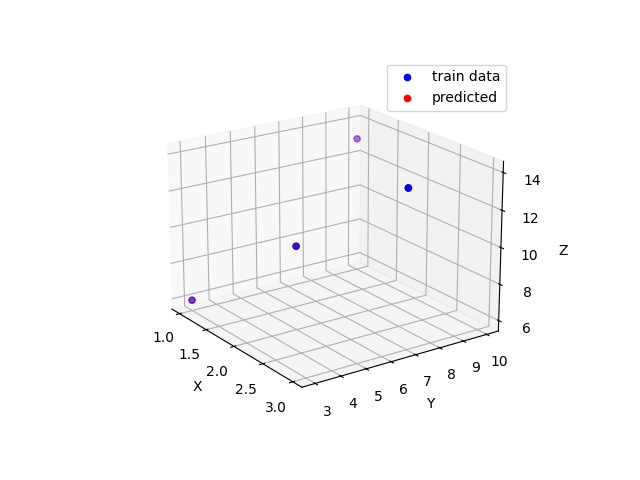

In [ ]:


# Test learn function with 2 columns
xs = [1, 2, 3]
example_x = np.array([[1, 3], [2, 5], [3, 7], [1, 10]]) # Shape (3, 2)
example_y = np.array([1 + 2*1 + 3, 1 + 2*2 + 5, 1 + 2*3 + 7, 1+2*1+10])
# Solution: y = 1 + 2 * xsub0 + 1 * xsub1

weights, weight_history, error_history, loss_sum = learn(0.001, 15000, 1, example_x, example_y)
print(f"WEIGHTS: {weights}")
# showHistory(error_history[100000-100:-1], "Error History")
print(f"Last error: {error_history[len(error_history) - 1]}")
weight_history = np.array(weight_history)

sample = np.array([1,3])
deg = 1
exp_input_n = [sample ** i for i in range(deg + 1)] # The first row is for the bias value
pred_val = np.sum(np.array(weights * np.array(exp_input_n))) 
print(pred_val)

# print solution
ax = plt.figure().add_subplot(projection='3d')
x1 = example_x[:,0]
x2 = example_x[:,1]
ax.scatter(x1, x2, zs=example_y.flatten(), zdir='z', c= 'b', label='train data')
# colors = ('r', 'g', 'b', 'k')
# np.random.seed(19680801)
# x = np.random.sample(20 * len(colors))
# y = np.random.sample(20 * len(colors))
# c_list = []
# for c in colors:
    # c_list.extend([c] * 20)
pred_vals = []
diff = []
for i, sample in enumerate(example_x):
    pred = predict_with_weights(weights, sample, 1)
    pred_vals.append(pred)
    diff.append(example_y[i] - pred)
print(pred_vals)
print("Differences ", diff)
ax.scatter(x1, x2, zs=pred_vals, c='r', label='predicted')
ax.legend()
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

print("\n3,7 example")
print(example_x[2])
print(example_y[2])


exp_input_n = np.array(sample)
weighted_input_n = np.array(weights * exp_input_n)
pred = np.sum(weighted_input_n) 

# Customize the view angle so it's easier to see that the scatter points lie
# on the plane y=0
ax.view_init(elev=20., azim=-35, roll=0)

%matplotlib ipympl
%matplotlib widget

plt.show()

# Part 2

Gen AI: I used Chat GPT to understand what a basis function is when used in the context of Machine Learning. 

In [ ]:
#House ID,Bathrooms,Land Area,Living area,# Garages,# Rooms,# Bedrooms,Age of home,Price

housing_train_output = housing_train["price"]

housing_train_input = [0] * len(housing_train)
for i, row in enumerate(housing_train):
    row = np.array([row[0], row[1], row[2], row[3], row[4], row[5], row[6], row[7]])
    housing_train_input[i] = row

housing_train_input = np.array(housing_train_input)
print(np.shape(housing_train_input))

In [ ]:
weights, weight_history, error_history, final_loss = learn(0.0000001, 10000, 1, housing_train_input, housing_train_output)

print("Weights")
print(weights)


n = 'land'

housing_train = np.array(housing_train)

print(f"Final loss: {final_loss}")
print("Error history")
print(error_history)

# Training
plt.scatter(housing_train[n], housing_train["price"])
x_space = np.linspace(np.min(housing_train[n]), np.max(housing_train[n]))
num_weights = weights.shape[1]
model_predictions =  [np.sum(weights * [x ** i for i in range(num_weights)]) for x in x_space]
plt.plot(x_space, model_predictions)
plt.title("Training data with Model")
plt.show()

# Test
plt.scatter(housing_test[n], housing_test["price"])
x_space = np.linspace(np.min(housing_test[n]), np.max(housing_test[n]))
num_weights = weights.shape[1]
model_predictions =  [np.sum(weights * [x ** i for i in range(num_weights)]) for x in x_space]
plt.plot(x_space, model_predictions)
plt.title("Test data with Model")
plt.show()

# Plot history of error
error_history = np.array(error_history)
plt.scatter([i for i in range(0, len(error_history))], error_history)
plt.title(f"Error history")
plt.show()

Weights
[[ 1248.41693431  1247.39221234  1247.37551732  1247.45071462
   1247.45091293  1247.39804225  1247.43610459  1247.42637678]
 [19254.44577282  4134.44690769 19098.37379522  5293.4588951
   3380.78522238 14093.10511332  7366.57659582  5096.33022213]]
Final loss: [[  483757.20673873   483757.20673873   483757.20673873   483757.20673873
    483757.20673873   483757.20673873   483757.20673873   483757.20673873]
 [ 3846852.56810258  2825314.20449116 11097454.38797646  3718261.79286681
   2330291.18755928  8559145.67161768  4744931.34083072 -4606918.76619415]]
Error history
[np.float64(1041853110.405195), np.float64(1038555827.9695292), np.float64(1035270000.4240835), np.float64(1031995587.8418809), np.float64(1028732550.4351325), np.float64(1025480848.5547527), np.float64(1022240442.6898742), np.float64(1019011293.4673684), np.float64(1015793361.6513635), np.float64(1012586608.1427672), np.float64(1009390993.9787889), np.float64(1006206480.3324645), np.float64(1003033028.512184), np

In [ ]:
data_formats = {'names': ('id', 'baths', 'land', 'living', 'garages', 'rooms','beds','age', 'price'), 'formats':('i2', 'f2', 'f4','f4', 'f4', 'i4', 'i4','i4','f8')}
housing_train = np.loadtxt("train.csv", delimiter=',', skiprows=1, dtype=data_formats)
housing_test = np.loadtxt("test.csv", delimiter=',', skiprows=1, dtype=data_formats)
#House ID,Bathrooms,Land Area,Living area,# Garages,# Rooms,# Bedrooms,Age of home,Price

housing_train_output = housing_train["price"]

# for n in data_formats["names"]:
#     if n == 'price':
#         continue
#     print("\n\n", n)
#     housing_train_input = housing_train[n]

#     weights, weight_history, error_history, final_loss = learn(0.00001, 200, 4, housing_train_input, housing_train_output)


#     plt.scatter(housing_test[n], housing_test["price"])
#     x_space = np.linspace(np.min(housing_test[n]), np.max(housing_test[n]))
#     num_weights = weights.size()
#     model_predictions =  [np.sum(weights * [x ** i for i in range(num_weights)]) for x in x_space]
#     plt.plot(x_space, model_predictions)
#     plt.title("Test data with Model")
#     plt.show()
    
#     # Plot history of error
#     error_history = np.array(error_history)
#     plt.scatter([i for i in range(0, len(error_history))], error_history)
#     plt.title(f"Error history")
#     plt.show()

